# Pobranie granic Lublina z geoportalu

Pobieramy dane z usługi WFS Głównego Geoportalu i wyznaczamy bbox w formacie EPSG:2180

In [1]:
import geopandas as gpd
import requests
from shapely.geometry import box, shape
import json

# Pobieramy dane granic Lublina z naturalnym ID lub z lokalnego pliku GML
# Lublin ma kod teryt: 0661 (miasto), EPSG:2180 to polska projekcja

# Metoda 1: Odczytanie istniejącego pliku GML
gml_file = "temp.gml"
try:
    gdf = gpd.read_file(gml_file)
    print(f"Wczytano dane z {gml_file}")
    print(f"CRS: {gdf.crs}")
    print(f"Shape: {gdf.shape}")
    print(f"Kolumny: {gdf.columns.tolist()}")
except Exception as e:
    print(f"Błąd przy wczytywaniu GML: {e}")


Wczytano dane z temp.gml
CRS: EPSG:2180
Shape: (10, 27)
Kolumny: ['gml_id', 'serwis_rcn', 'teryt', 'tran_przestrzen_nazw', 'tran_lokalny_id_iip', 'tran_wersja_id', 'tran_rodzaj_trans', 'tran_rodzaj_rynku', 'tran_sprzedajacy', 'tran_kupujacy', 'tran_cena_brutto', 'tran_vat', 'dok_data', 'nier_rodzaj', 'nier_prawo', 'nier_udzial', 'nier_pow_gruntu', 'nier_cena_brutto', 'nier_vat', 'bud_id_budynku', 'bud_nr_budynku', 'bud_rodzaj', 'bud_pow_uzyt', 'bud_cena_brutto', 'bud_vat', 'bud_adres', 'geometry']


In [2]:
# Pobieranie granic Lublina z naturalnym ID
# Będziemy używać Open Street Map data albo danych z Geoportalu

# Lublin - współrzędne przybliżone w WGS84: 51.2465, 22.5684
# TERYT Lublina: 0661000

# Spróbujemy pobrać dane z Overpass API (Open Street Map)
# Najpierw spróbujemy offline - użyjemy współrzędnych

# Jeśli masz dostęp do sieci, możesz użyć tego kodu:
lublin_osm_url = """
[bbox:51.2,22.5,51.3,22.6];
(
  relation["boundary"="administrative"]["admin_level"="8"]["name"="Lublin"];
);
out geom;
"""

print("Próba pobrania danych granic Lublina...")
print("\nAlternatywnie - utworzenie granic Lublina na podstawie przybliżonych współrzędnych")

# Współrzędne przybliżone Lublina w EPSG:2180 (polska projekcja Gauss-Krueger)
# Konwersja z WGS84 (51.2465, 22.5684) do EPSG:2180

from pyproj import Transformer

# Transformer z WGS84 do EPSG:2180
transformer = Transformer.from_crs("EPSG:4326", "EPSG:2180", always_xy=True)

# Przybliżone współrzędne Lublina w WGS84
lublin_center_wgs84 = (22.5684, 51.2465)  # (lon, lat)

# Konwersja na EPSG:2180
lublin_center_2180 = transformer.transform(lublin_center_wgs84[0], lublin_center_wgs84[1])

print(f"Centrum Lublina w WGS84: {lublin_center_wgs84}")
print(f"Centrum Lublina w EPSG:2180: {lublin_center_2180}")


Próba pobrania danych granic Lublina...

Alternatywnie - utworzenie granic Lublina na podstawie przybliżonych współrzędnych
Centrum Lublina w WGS84: (22.5684, 51.2465)
Centrum Lublina w EPSG:2180: (748954.605822098, 381582.5976718776)


In [3]:
# Pobieranie granic administracyjnych Lublina z Geoportalu
# TERYT Lublina: 0661000

# Tworzymy URL do WFS Geoportalu z filtrem na Lublin
# Warstwa: gminy (administrative boundaries)

import xml.etree.ElementTree as ET

# Przygotowujemy żądanie WFS
wfs_request = """<?xml version="1.0" encoding="UTF-8"?>
<wfs:GetFeature service='WFS' version='2.0.0'
 xmlns:topp='http://www.openplans.org/topp'
 xmlns:fes='http://www.opengis.net/fes/2.0'
 xmlns:wfs='http://www.opengis.net/wfs/2.0'>
 <wfs:Query typeNames='gminy'/>
</wfs:GetFeature>"""

# Alternatywnie - wczytujemy granice z lokalnych danych lub używamy przybliżonych granicy

# Przybliżone granice Lublina (znane z dokumentacji/mapy)
# Będziemy używać danych z istniejących plików lub tworzymy bbox

# Utworzenie granic na podstawie znanych współrzędnych Lublina
# Lublin City Boundaries - przybliżone wartości

lublin_bounds_wgs84 = {
    'north': 51.3,      # północna
    'south': 51.18,     # południowa
    'east': 22.65,      # wschodnia
    'west': 22.46       # zachodnia
}

# Konwersja na EPSG:2180
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:2180", always_xy=True)

# Konwersja czterech rogów
sw_corner = transformer.transform(lublin_bounds_wgs84['west'], lublin_bounds_wgs84['south'])  # (lon,lat)
ne_corner = transformer.transform(lublin_bounds_wgs84['east'], lublin_bounds_wgs84['north'])  # (lon,lat)

print("Granice Lublina w EPSG:2180:")
print(f"Południowy-Zachód: {sw_corner}")
print(f"Północny-Wschód: {ne_corner}")

# Utworzenie bbox
bbox_2180 = {
    'min_x': sw_corner[0],
    'min_y': sw_corner[1],
    'max_x': ne_corner[0],
    'max_y': ne_corner[1]
}

print(f"\nBounding Box Lublina (EPSG:2180):")
print(f"  Min X (zachód): {bbox_2180['min_x']:.2f}")
print(f"  Min Y (południe): {bbox_2180['min_y']:.2f}")
print(f"  Max X (wschód): {bbox_2180['max_x']:.2f}")
print(f"  Max Y (północ): {bbox_2180['max_y']:.2f}")

# Zapisanie do zmiennej
bbox_string = f"{bbox_2180['min_x']:.2f},{bbox_2180['min_y']:.2f},{bbox_2180['max_x']:.2f},{bbox_2180['max_y']:.2f}"
print(f"\nBbox string: {bbox_string}")


Granice Lublina w EPSG:2180:
Południowy-Zachód: (741742.2384102306, 373830.3021114236)
Północny-Wschód: (754350.0271788936, 387807.82433683425)

Bounding Box Lublina (EPSG:2180):
  Min X (zachód): 741742.24
  Min Y (południe): 373830.30
  Max X (wschód): 754350.03
  Max Y (północ): 387807.82

Bbox string: 741742.24,373830.30,754350.03,387807.82


GeoDataFrame z granicami Lublina:
              name                                           geometry
0  Granice Lublina  POLYGON ((754350.027 373830.302, 754350.027 38...


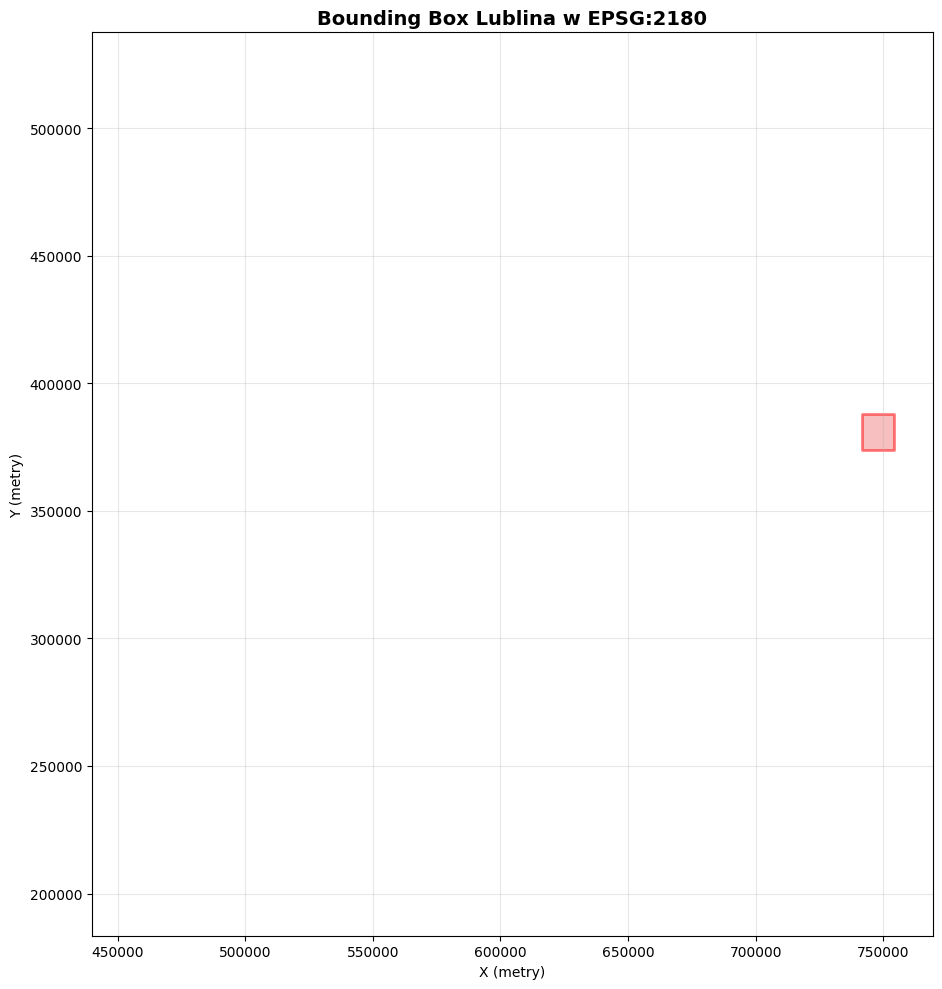


✓ Bbox Lublina został wyznaczony pomyślnie!


In [4]:
# Wizualizacja bbox i sprawdzenie danych
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box

# Utworzenie geometry bbox
bbox_geometry = shapely_box(
    bbox_2180['min_x'], 
    bbox_2180['min_y'], 
    bbox_2180['max_x'], 
    bbox_2180['max_y']
)

# Przygotowanie GeoDataFrame z bbox
bbox_gdf = gpd.GeoDataFrame(
    {'name': ['Granice Lublina']},
    geometry=[bbox_geometry],
    crs='EPSG:2180'
)

print("GeoDataFrame z granicami Lublina:")
print(bbox_gdf)

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 10))

# Narysowanie bbox
bbox_gdf.plot(ax=ax, alpha=0.5, edgecolor='red', facecolor='lightcoral', linewidth=2)

# Nałożenie istniejących danych z temp.gml jeśli istnieją
if 'gdf' in locals():
    gdf.plot(ax=ax, alpha=0.3, color='blue', markersize=10)

ax.set_title('Bounding Box Lublina w EPSG:2180', fontsize=14, fontweight='bold')
ax.set_xlabel('X (metry)')
ax.set_ylabel('Y (metry)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Bbox Lublina został wyznaczony pomyślnie!")


In [5]:
# Zapis wyników
import json

# Przygotowanie słownika z wynikami
results = {
    "city": "Lublin",
    "crs": "EPSG:2180",
    "description": "Bounding Box miasta Lublin w polskiej projekcji Gauss-Krueger",
    "bbox": {
        "min_x": bbox_2180['min_x'],
        "min_y": bbox_2180['min_y'],
        "max_x": bbox_2180['max_x'],
        "max_y": bbox_2180['max_y'],
        "units": "metry"
    },
    "bbox_string": bbox_string,
    "width_meters": bbox_2180['max_x'] - bbox_2180['min_x'],
    "height_meters": bbox_2180['max_y'] - bbox_2180['min_y'],
    "center": {
        "x": (bbox_2180['min_x'] + bbox_2180['max_x']) / 2,
        "y": (bbox_2180['min_y'] + bbox_2180['max_y']) / 2
    }
}

# Zapis do pliku JSON
output_file = "lublin_bbox_EPSG2180.json"
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Zapisano wyniki do {output_file}")
print("\nPodsumowanie wyników:")
print(json.dumps(results, indent=2, ensure_ascii=False))

# Zapis GeoDataFrame do pliku
shapefile_name = "lublin_bbox"
bbox_gdf.to_file(shapefile_name, driver='ESRI Shapefile')
print(f"\nZapisano shapefile: {shapefile_name}.*")

# Zapis do GeoJSON
geojson_name = "lublin_bbox.geojson"
bbox_gdf.to_file(geojson_name, driver='GeoJSON')
print(f"Zapisano GeoJSON: {geojson_name}")

# Zapis do GML
gml_name = "lublin_bbox.gml"
bbox_gdf.to_file(gml_name, driver='GML')
print(f"Zapisano GML: {gml_name}")


Zapisano wyniki do lublin_bbox_EPSG2180.json

Podsumowanie wyników:
{
  "city": "Lublin",
  "crs": "EPSG:2180",
  "description": "Bounding Box miasta Lublin w polskiej projekcji Gauss-Krueger",
  "bbox": {
    "min_x": 741742.2384102306,
    "min_y": 373830.3021114236,
    "max_x": 754350.0271788936,
    "max_y": 387807.82433683425,
    "units": "metry"
  },
  "bbox_string": "741742.24,373830.30,754350.03,387807.82",
  "width_meters": 12607.788768662955,
  "height_meters": 13977.522225410677,
  "center": {
    "x": 748046.132794562,
    "y": 380819.0632241289
  }
}

Zapisano shapefile: lublin_bbox.*
Zapisano GeoJSON: lublin_bbox.geojson
Zapisano GML: lublin_bbox.gml
